# Text Analytics

## Sentiment Classification

### Loading the dataset

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

train_ds = pd.read_csv( "sentiment_train", delimiter="\t" )
train_ds.head( 5 )

,sentiment,text
0,1,The Da Vinci Code book is just awesome.
1,1,this was the first clive cussler i've ever rea...
2,1,i liked the Da Vinci Code a lot.
3,1,i liked the Da Vinci Code a lot.
4,1,I liked the Da Vinci Code but it ultimately di...


In [2]:
pd.set_option('max_colwidth', 800)
train_ds[train_ds.sentiment == 1][0:5]

,sentiment,text
0,1,The Da Vinci Code book is just awesome.
1,1,"this was the first clive cussler i've ever read, but even books like Relic, and Da Vinci code were more plausible than this."
2,1,i liked the Da Vinci Code a lot.
3,1,i liked the Da Vinci Code a lot.
4,1,I liked the Da Vinci Code but it ultimately didn't seem to hold it's own.


In [3]:
train_ds[train_ds.sentiment == 0][0:5]

,sentiment,text
3943,0,da vinci code was a terrible movie.
3944,0,"Then again, the Da Vinci code is super shitty movie, and it made like 700 million."
3945,0,"The Da Vinci Code comes out tomorrow, which sucks."
3946,0,i thought the da vinci code movie was really boring.
3947,0,"God, Yahoo Games has this truly-awful looking Da Vinci Code-themed skin on it's chessboard right now."


### Exploring the dataset

In [4]:
train_ds.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6918 entries, 0 to 6917
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  6918 non-null   int64 
 1   text       6918 non-null   object
dtypes: int64(1), object(1)
memory usage: 108.2+ KB


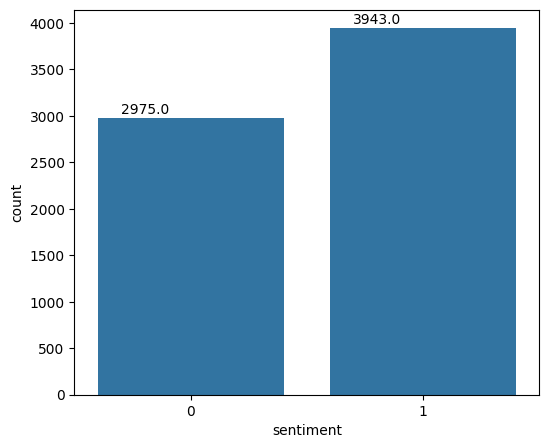

In [5]:
import matplotlib.pyplot as plt
import seaborn as sn

plt.figure( figsize=(6,5))
# create count plot
ax = sn.countplot(x='sentiment', data=train_ds)
# annotate
for p in ax.patches:
        ax.annotate(p.get_height(), (p.get_x()+0.1, p.get_height()+50))

### Text Preprocessing

#### Creating Count Vectors for *sentiment_train* dataset

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer
count_vectorizer = CountVectorizer()
# Create the dictionary from the corpus
feature_vector = count_vectorizer.fit( train_ds.text )
# Get the feature names
features = list(feature_vector.get_feature_names_out())
print( "Total number of features: ", len(features))

Total number of features:  2132


In [7]:
import random

random.sample(features, 10)

['jokes',
 'favor',
 'search',
 'coming',
 'involve',
 'azkaban',
 'main',
 'sam',
 'enough',
 'latest']

In [8]:
train_ds_features = count_vectorizer.transform( train_ds.text )
type(train_ds_features)

scipy.sparse._csr.csr_matrix

In [9]:
train_ds_features.shape

(6918, 2132)

In [10]:
train_ds_features.getnnz()

65398

In [11]:
print( "Density of the matrix: ",
      train_ds_features.getnnz() * 100 /
      (train_ds_features.shape[0] * train_ds_features.shape[1]))

Density of the matrix:  0.4434010415225908


#### Displaying Document Vectors

In [12]:
# Converting the matrix to a dataframe
train_ds_df = pd.DataFrame(train_ds_features.todense())
# Setting the column names to the features i.e. words
train_ds_df.columns = features

In [13]:
train_ds[0:1]

,sentiment,text
0,1,The Da Vinci Code book is just awesome.


In [14]:
train_ds_df.iloc[0:1, 150:157]

,away,awesome,awesomely,awesomeness,awesomest,awful,awkward
0,0,1,0,0,0,0,0


In [15]:
train_ds_df[['the', 'da', "vinci", "code", "book", 'is', 'just', 'awesome']][0:1]

,the,da,vinci,code,book,is,just,awesome
0,1,1,1,1,1,1,1,1


####  Removing low frequency words

In [16]:
# summing up the occurrences of features column wise
features_counts = np.sum( train_ds_features.toarray(), axis = 0 )
feature_counts_df = pd.DataFrame( dict( features = features,
                                    counts = features_counts ) )

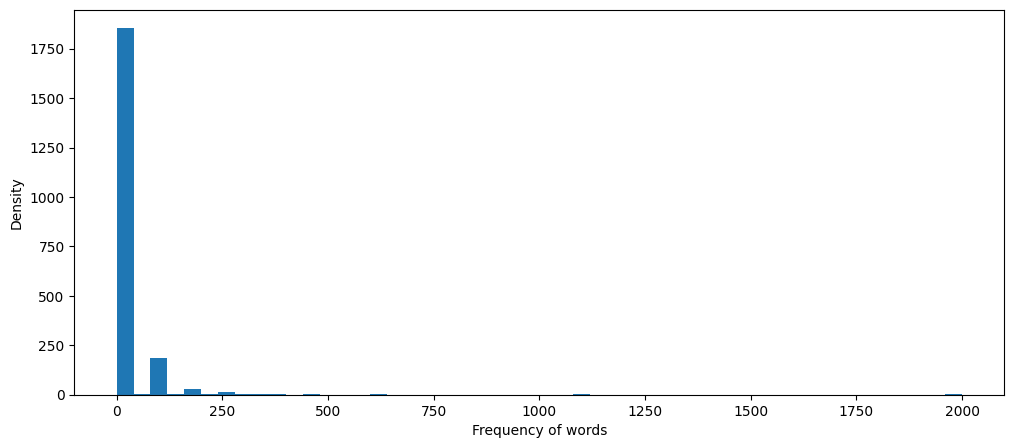

In [17]:
plt.figure( figsize=(12,5))
plt.hist(feature_counts_df.counts, bins=50, range = (0, 2000));
plt.xlabel( 'Frequency of words' )
plt.ylabel( 'Density' );

In [18]:
len(feature_counts_df[feature_counts_df.counts == 1])

1228

In [19]:
# Initialize the CountVectorizer
count_vectorizer = CountVectorizer(max_features=1000)
# Create the dictionary from the corpus
feature_vector = count_vectorizer.fit( train_ds.text )
# Get the feature names
features = list(feature_vector.get_feature_names_out())
# Transform the document into vectors
train_ds_features = count_vectorizer.transform( train_ds.text )
# Count the frequency of the features
features_counts = np.sum( train_ds_features.toarray(), axis = 0 )
feature_counts = pd.DataFrame( dict( features = features,
                                    counts = features_counts ) )

In [20]:
feature_counts.sort_values('counts',
                           ascending = False)[0:15]

,features,counts
858,the,3306
49,and,2154
379,harry,2093
705,potter,2093
150,code,2002
190,da,2001
926,vinci,2001
616,mountain,2000
116,brokeback,2000
576,love,1624


#### Removing Stop Words

In [21]:
from sklearn.feature_extraction import text

my_stop_words = text.ENGLISH_STOP_WORDS

#Printing first few stop words
print("Few stop words: ", list(my_stop_words)[0:10])

Few stop words:  ['hasnt', 'twelve', 'between', 'hundred', 'along', 'any', 'go', 'ever', 'seeming', 'would']


In [22]:
# Adding custom words to the list of stop words
my_stop_words = list(text.ENGLISH_STOP_WORDS.union( ['harry', 'potter', 'code', 'vinci', 'da',
                                                'harry', 'mountain', 'movie', 'movies']))

#### Creating Count Vectors

In [23]:
# Setting stop words list
count_vectorizer = CountVectorizer( stop_words = my_stop_words,
                                   max_features = 1000 )
feature_vector = count_vectorizer.fit( train_ds.text )
train_ds_features = count_vectorizer.transform( train_ds.text )
features = list(feature_vector.get_feature_names_out())
features_counts = np.sum( train_ds_features.toarray(), axis = 0 )
feature_counts = pd.DataFrame( dict( features = features,
                                    counts = features_counts ) )

In [24]:
feature_counts.sort_values( "counts", ascending = False )[0:15]

,features,counts
84,brokeback,2000
682,love,1624
50,awesome,1127
710,mission,1094
552,impossible,1093
664,like,974
882,sucks,602
880,sucked,600
452,hate,578
793,really,374


In [25]:
from nltk.stem.snowball import PorterStemmer

stemmer = PorterStemmer()
analyzer = CountVectorizer().build_analyzer()

#Custom function for stemming and stop word removal

def stemmed_words(doc):
    ### Stemming of words
    stemmed_words = (stemmer.stem(w) for w in analyzer(doc))
    ### Remove the words in stop words list
    non_stop_words = [ word for word in list(set(stemmed_words) - set(my_stop_words)) ]
    return non_stop_words

In [26]:
count_vectorizer = CountVectorizer( analyzer=stemmed_words,
                                   max_features = 1000)
feature_vector = count_vectorizer.fit( train_ds.text )
train_ds_features = count_vectorizer.transform( train_ds.text )
features = list(feature_vector.get_feature_names_out())
features_counts = np.sum( train_ds_features.toarray(), axis = 0 )
feature_counts = pd.DataFrame( dict( features = features,
                                    counts = features_counts ) )
feature_counts.sort_values( "counts", ascending = False )[0:15]

,features,counts
93,brokeback,1930
418,harri,1916
662,love,1837
893,suck,1378
951,wa,1142
56,awesom,1116
509,imposs,1090
719,mission,1090
725,movi,1052
633,like,823


#### Distribution of words across different sentiment

In [27]:
# Convert the document vector matrix into dataframe
train_ds_df = pd.DataFrame(train_ds_features.todense())
# Assign the features names to the column
train_ds_df.columns = features
# Assign the sentiment labels to the train_ds
train_ds_df['sentiment'] = train_ds.sentiment

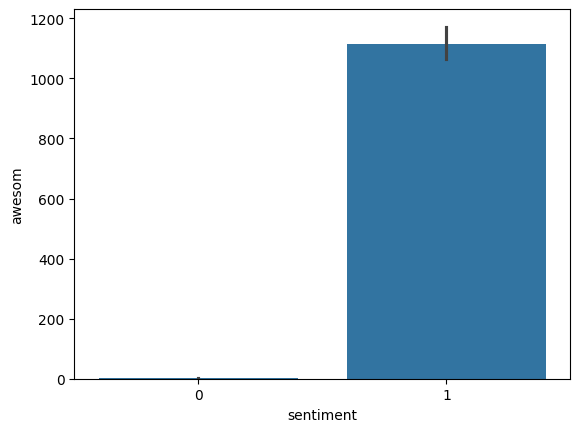

In [28]:
sn.barplot( x = 'sentiment', y = 'awesom', data = train_ds_df, estimator=sum );

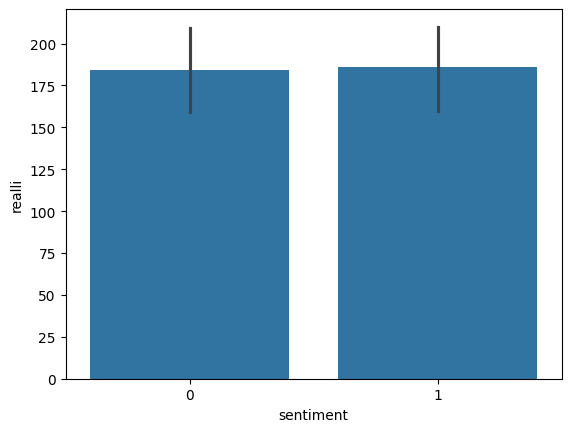

In [29]:
sn.barplot( x = 'sentiment', y = 'realli', data = train_ds_df, estimator=sum );

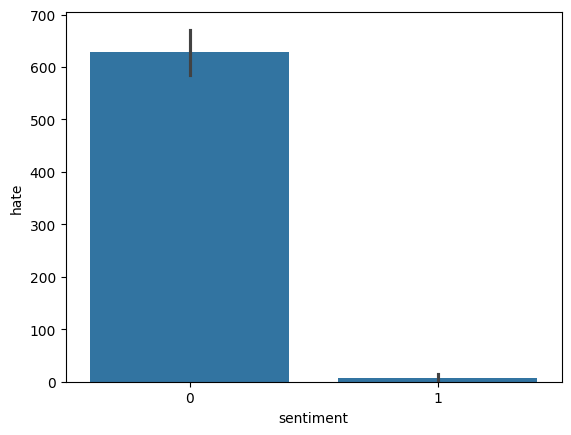

In [30]:
sn.barplot( x = 'sentiment', y = 'hate', data = train_ds_df, estimator=sum );

### Naive Bayes Model for Sentiment Classification

#### Split the dataset

In [31]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split( train_ds_features,
                                                    train_ds.sentiment,
                                                    test_size = 0.3,
                                                    random_state = 42 )

#### Build Naive Bayes Model

In [32]:
from sklearn.naive_bayes import BernoulliNB

nb_clf = BernoulliNB()
nb_clf.fit( train_X.toarray(), train_y )

BernoulliNB()

#### Make prediction on test case

In [33]:
test_ds_predicted = nb_clf.predict( test_X.toarray() )

#### Print clasification report

In [34]:
from sklearn import metrics

print( metrics.classification_report( test_y, test_ds_predicted ) )

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       873
           1       0.98      0.99      0.98      1203

    accuracy                           0.98      2076
   macro avg       0.98      0.98      0.98      2076
weighted avg       0.98      0.98      0.98      2076



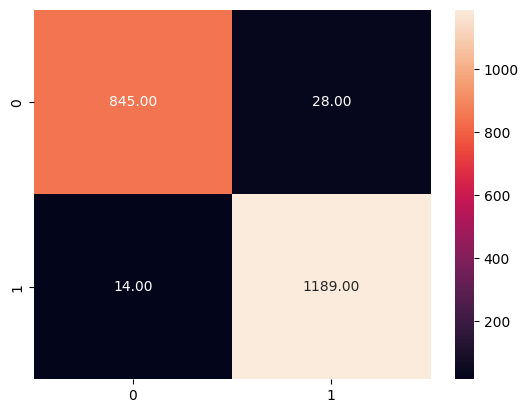

In [35]:
from sklearn import metrics

cm = metrics.confusion_matrix( test_y, test_ds_predicted )
sn.heatmap(cm, annot=True,  fmt='.2f' );

### Using TF-IDF Vectorizer

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer( analyzer=stemmed_words,
                                   max_features = 1000)
feature_vector = tfidf_vectorizer.fit( train_ds.text )
train_ds_features = tfidf_vectorizer.transform( train_ds.text )
features = list(feature_vector.get_feature_names_out())

In [37]:
from sklearn.naive_bayes import GaussianNB

train_X, test_X, train_y, test_y = train_test_split( train_ds_features,
                                                    train_ds.sentiment,
                                                    test_size = 0.3,
                                                    random_state = 42 )

nb_clf = GaussianNB()
nb_clf.fit( train_X.toarray(), train_y )

GaussianNB()

In [38]:
test_ds_predicted = nb_clf.predict( test_X.toarray() )
print( metrics.classification_report( test_y, test_ds_predicted ) )

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       873
           1       0.97      0.97      0.97      1203

    accuracy                           0.97      2076
   macro avg       0.96      0.96      0.96      2076
weighted avg       0.97      0.97      0.97      2076



### Build a Random Forest Model to find important words

In [39]:
from sklearn.ensemble import RandomForestClassifier

# Adding custom words to the list of stop words
my_stop_words = list(text.ENGLISH_STOP_WORDS.union( ['harry', 'potter', 'code', 'vinci', 'da',
                                                     'harry', 'mountain', 'movie', 'movies', 'impossible',
                                                     'mission', 'mountain', 'brokeback']))

# Create the vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=500,
                                   stop_words=my_stop_words)

feature_vector = tfidf_vectorizer.fit( train_ds.text )
train_ds_features = tfidf_vectorizer.transform( train_ds.text )
features = list(feature_vector.get_feature_names_out())

# Split the dataset into train and test sets
train_X, test_X, train_y, test_y = train_test_split( train_ds_features,
                                                    train_ds.sentiment,
                                                    test_size = 0.3,
                                                    random_state = 42 )
# Build Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators = 200,
                                max_depth = 10,
                                random_state = 42)
rf_clf.fit( train_X.toarray(), train_y )

# Predict on test set and print the classification report
test_ds_predicted = rf_clf.predict( test_X.toarray() )
print( metrics.classification_report( test_y, test_ds_predicted ) )

              precision    recall  f1-score   support

           0       1.00      0.95      0.97       873
           1       0.97      1.00      0.98      1203

    accuracy                           0.98      2076
   macro avg       0.98      0.97      0.98      2076
weighted avg       0.98      0.98      0.98      2076



In [40]:
important_words = pd.DataFrame({ "words": features,
                                 "importance": rf_clf.feature_importances_} )
important_words.sort_values("importance", ascending = False)[0:10]

,words,importance
277,love,0.135046
27,awesome,0.110355
423,sucked,0.098155
205,hate,0.071611
425,sucks,0.063732
262,like,0.050211
421,stupid,0.039827
422,suck,0.034387
225,horrible,0.021876
243,just,0.021568
